# 🔍 Concrete Crack Anomaly Detection — Autoencoder (Fixed)
## Strategy
Train a Convolutional Autoencoder **only** on **Non-Cracked** images.
- **Non-Cracked** → model reconstructs well → **high similarity** → ✅ PASSED
- **Cracked** → model never saw cracks → **low similarity** → 🔴 FLAGGED

## How to use this notebook
Each cell saves its outputs (model weights, arrays, records) to disk.  
If a cell fails mid-run, **do not restart from Cell 1** — just re-run the failed cell.  
The only exception is if you change `SIMILARITY_THRESHOLD` — then re-run from Cell 6 onwards.

## 📦 Cell 1 — Imports

In [1]:
import os, cv2, warnings, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, roc_auc_score,
    f1_score, precision_score, recall_score, accuracy_score,
)
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model, callbacks
    from tensorflow.keras.optimizers import Adam
    print(f"✔  TensorFlow {tf.__version__} ready")
    print(f"   GPUs available: {len(tf.config.list_physical_devices('GPU'))}")
except ImportError:
    raise ImportError("Run:  pip install tensorflow")

print("✔  All imports successful")

✔  TensorFlow 2.20.0 ready
   GPUs available: 0
✔  All imports successful


## ⚙️ Cell 2 — Configuration
> **`SIMILARITY_THRESHOLD`** is the only value you need to tune.
> Images with similarity **below** this are flagged as Cracked.
> - Higher → more sensitive (catches more cracks, more false positives)
> - Lower  → less sensitive (fewer false alarms, may miss subtle cracks)
> 
> If you change this, re-run from **Cell 6** onwards — no need to retrain.

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              CONFIGURATION  —  TUNE HERE                    ║
# ╠══════════════════════════════════════════════════════════════╣
# ║  SIMILARITY_THRESHOLD : images below this → flagged CRACKED ║
# ║  Range: 0.0 – 1.0   |   Recommended start: 0.55            ║
# ║                                                              ║
# ║  To retune: change value, then re-run Cell 6 onwards only   ║
# ╚══════════════════════════════════════════════════════════════╝

SIMILARITY_THRESHOLD = 0.55   # ← TUNE THIS

BASE_PATH = r"C:\Users\Kritvi Gera\Desktop\ICL\Data Project\2. Image processing\Project_Vision_Data_Group_A\Project_Vision_Data_Group_A_Processed"

POOLS = {
    "Walls": os.path.join(BASE_PATH, "Training_Pool_A_Walls"),
    "Decks": os.path.join(BASE_PATH, "Training_Pool_B_Decks"),
}

LABEL_MAP   = {"Cracked": 1, "Non-Cracked": 0}
LABEL_NAMES = {1: "Cracked", 0: "Non-Cracked"}

IMAGE_SIZE    = (128, 128)
BATCH_SIZE    = 32
EPOCHS        = 80
LATENT_DIM    = 32
LEARNING_RATE = 1e-3
SUPPORTED_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# Checkpoint paths — all intermediate results saved here
SAVE_DIR          = "ae_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
PATH_MODEL        = os.path.join(SAVE_DIR, "autoencoder.keras")
PATH_ERRORS       = os.path.join(SAVE_DIR, "errors.npz")
PATH_RECORDS      = os.path.join(SAVE_DIR, "records.pkl")
PATH_IMGS_NORMAL  = os.path.join(SAVE_DIR, "imgs_normal.npy")
PATH_IMGS_ANOMALY = os.path.join(SAVE_DIR, "imgs_anomaly.npy")

print("✔  Configuration loaded")
print(f"   SIMILARITY_THRESHOLD = {SIMILARITY_THRESHOLD}")
print(f"   IMAGE_SIZE           = {IMAGE_SIZE}")
print(f"   LATENT_DIM           = {LATENT_DIM}")
print(f"   Checkpoints folder   = {SAVE_DIR}/")

✔  Configuration loaded
   SIMILARITY_THRESHOLD = 0.55
   IMAGE_SIZE           = (128, 128)
   LATENT_DIM           = 32
   Checkpoints folder   = ae_checkpoints/


## 🛠️ Cell 3 — Helper & Preprocessing Functions

In [3]:
def error_to_similarity(error: float, ref: float) -> float:
    """Convert MSE reconstruction error → similarity score in [0, 1].
    1.0 = identical to normal concrete.  0.0 = completely different."""
    return float(1.0 - (error / (error + ref + 1e-9)))


def preprocess(img_path: str) -> np.ndarray:
    """Load greyscale image → denoise → CLAHE → resize → normalise [0,1]."""
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)  # load directly as grey
    if img is None:
        raise FileNotFoundError(f"Cannot read: {img_path}")
    
    denoised = cv2.fastNlMeansDenoising(img, h=10)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    resized  = cv2.resize(enhanced, IMAGE_SIZE)
    normed   = resized.astype(np.float32) / 255.0
    return normed[:, :, np.newaxis]   # shape: (H, W, 1)


print("✔  Helper functions defined")

✔  Helper functions defined


## 📂 Cell 4 — Load Dataset
**Saves to disk:** `imgs_normal.npy`, `imgs_anomaly.npy`, `records.pkl`  
**Skip this cell** if those files already exist and you haven't changed your data.

In [4]:
from concurrent.futures import ThreadPoolExecutor, as_completed

# ── Check if already cached ───────────────────────────────────────────────────
if (os.path.exists(PATH_IMGS_NORMAL) and
    os.path.exists(PATH_IMGS_ANOMALY) and
    os.path.exists(PATH_RECORDS)):
    
    print("✔  Found saved dataset — loading from cache (skipping re-processing)")
    imgs_normal  = np.load(PATH_IMGS_NORMAL)
    imgs_anomaly = np.load(PATH_IMGS_ANOMALY)
    with open(PATH_RECORDS, "rb") as f:
        records_normal, records_anomaly = pickle.load(f)
    print(f"  Non-Cracked : {len(imgs_normal)}")
    print(f"  Cracked     : {len(imgs_anomaly)}")

else:
    print("First run — processing all images with parallel loading...\n")

    def process_file(fp, pool_name, label_name, label_val):
        try:
            arr = preprocess(str(fp))
            rec = {"path": str(fp), "filename": fp.name,
                   "pool": pool_name, "section": label_name,
                   "label": label_val,
                   "error": None, "similarity": None,
                   "pred": None, "correct": None}
            return arr, rec, label_val
        except Exception as e:
            print(f"  ✗  {fp.name}: {e}")
            return None

    imgs_normal,   imgs_anomaly   = [], []
    records_normal, records_anomaly = [], []

    for pool_name, pool_path in POOLS.items():
        for label_name, label_val in LABEL_MAP.items():
            folder = os.path.join(pool_path, label_name)
            if not os.path.isdir(folder):
                print(f"  ⚠  Folder not found: {folder}")
                continue

            files = sorted([f for f in Path(folder).iterdir()
                            if f.suffix.lower() in SUPPORTED_EXT])
            print(f"  📂  {pool_name} / {label_name}: {len(files)} images", end=" ... ")

            with ThreadPoolExecutor(max_workers=8) as executor:
                futures = [executor.submit(process_file, fp, pool_name, label_name, label_val)
                           for fp in files]
                results = [f.result() for f in as_completed(futures)
                           if f.result() is not None]

            for arr, rec, lv in results:
                if lv == 0:
                    imgs_normal.append(arr);  records_normal.append(rec)
                else:
                    imgs_anomaly.append(arr); records_anomaly.append(rec)
            print("done")

    imgs_normal  = np.array(imgs_normal,  dtype=np.float32)
    imgs_anomaly = np.array(imgs_anomaly, dtype=np.float32)

    # Save to cache
    np.save(PATH_IMGS_NORMAL,  imgs_normal)
    np.save(PATH_IMGS_ANOMALY, imgs_anomaly)
    with open(PATH_RECORDS, "wb") as f:
        pickle.dump((records_normal, records_anomaly), f)
    print(f"\n✔  Saved to cache — future runs will skip this step entirely")
    print(f"  Non-Cracked : {len(imgs_normal)}")
    print(f"  Cracked     : {len(imgs_anomaly)}")

✔  Found saved dataset — loading from cache (skipping re-processing)
  Non-Cracked : 25684
  Cracked     : 5677


## ✂️ Cell 5 — Train / Validation Split

In [5]:
X_train, X_val = train_test_split(imgs_normal, test_size=0.15, random_state=42)

print(f"  Training set   : {len(X_train)} Non-Cracked images")
print(f"  Validation set : {len(X_val)}  Non-Cracked images")
print(f"  Cracked images : {len(imgs_anomaly)} (held-out — never seen in training)")

  Training set   : 21831 Non-Cracked images
  Validation set : 3853  Non-Cracked images
  Cracked images : 5677 (held-out — never seen in training)


## 🏗️ Cell 6 — Build the Autoencoder
**Bug fixed here:** `int(np.prod(flat_shape))` — converts numpy int64 → Python int so Keras Dense layer accepts it.

In [6]:
def build_autoencoder(input_shape=(128, 128, 1), latent_dim=32):
    """
    Convolutional Autoencoder.
    Trained ONLY on Non-Cracked images.
    Cracked images cannot be reconstructed → high MSE → flagged as anomaly.

    FIX: int(np.prod(flat_shape)) ensures Python int, not numpy int64.
    """
    inp = layers.Input(shape=input_shape, name="input")

    # ── ENCODER ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(32,  3, activation="relu", padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, padding="same")(x)           # → 64×64

    x = layers.Conv2D(64,  3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, padding="same")(x)           # → 32×32

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, padding="same")(x)           # → 16×16

    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, padding="same")(x)           # → 8×8

    flat_shape    = (8, 8, 256)
    flat_units    = int(np.prod(flat_shape))   # ← FIX: cast to Python int
    x      = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, name="bottleneck")(x)

    # ── DECODER ──────────────────────────────────────────────────────────────
    x = layers.Dense(flat_units, activation="relu")(latent)  # ← uses int
    x = layers.Reshape(flat_shape)(x)

    x = layers.Conv2DTranspose(256, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)                            # → 16×16

    x = layers.Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)                            # → 32×32

    x = layers.Conv2DTranspose(64,  3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)                            # → 64×64

    x = layers.Conv2DTranspose(32,  3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)                            # → 128×128

    out = layers.Conv2DTranspose(
        1, 3, activation="sigmoid", padding="same", name="output"
    )(x)

    autoencoder = Model(inp, out,    name="CrackAutoencoder")
    encoder     = Model(inp, latent, name="Encoder")
    autoencoder.compile(optimizer=Adam(LEARNING_RATE), loss="mse")
    return autoencoder, encoder


autoencoder, encoder = build_autoencoder(
    input_shape=(*IMAGE_SIZE, 1), latent_dim=LATENT_DIM
)
autoencoder.summary()
print("\n✔  Autoencoder built successfully")

Model: "CrackAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │       524,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16384)          │       540,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │        73,79

 Total params: 2,432,417 (9.28 MB)

 Trainable params: 2,431,457 (9.28 MB)

 Non-trainable params: 960 (3.75 KB)


✔  Autoencoder built successfully


## 🚀 Cell 7 — Train the Autoencoder
**Saves model to disk** after training so you never have to retrain unless you want to.  
**If model already exists on disk, this cell loads it instead of retraining.**

In [7]:
if os.path.exists(PATH_MODEL):
    print(f"✔  Found saved model at {PATH_MODEL}")
    print("   Loading from disk — skipping training.")
    print("   Delete the file and re-run this cell if you want to retrain.")
    autoencoder = tf.keras.models.load_model(PATH_MODEL)
    history = None
else:
    print(f"Training on {len(X_train)} Non-Cracked images (max {EPOCHS} epochs)...\n")

    cb = [
        callbacks.EarlyStopping(
            monitor="val_loss", patience=12,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=5, min_lr=1e-6, verbose=1
        ),
        callbacks.ModelCheckpoint(
            PATH_MODEL, monitor="val_loss",
            save_best_only=True, verbose=1
        ),
    ]

    history = autoencoder.fit(
        X_train, X_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, X_val),
        callbacks=cb,
        verbose=1,
    )

    print(f"\n✔  Training complete. Model saved to {PATH_MODEL}")

✔  Found saved model at ae_checkpoints\autoencoder.keras
   Loading from disk — skipping training.
   Delete the file and re-run this cell if you want to retrain.


## 📈 Cell 8 — Training History Plot
*(Only shows if model was trained this session — skip if loaded from disk)*

In [8]:
if history is not None:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(history.history["loss"],     label="Train Loss", color="#1565C0", lw=2)
    ax.plot(history.history["val_loss"], label="Val Loss",   color="#42A5F5", lw=2, ls="--")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.set_title("Autoencoder Training — Non-Cracked Images Only", fontsize=12)
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "training_history.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("✔  Saved: training_history.png")
else:
    print("ℹ  Model was loaded from disk — no training history to plot.")

ℹ  Model was loaded from disk — no training history to plot.


## 🔢 Cell 9 — Compute Reconstruction Errors
**Saves errors to disk.** Skip re-running this if errors are already saved and model hasn't changed.

In [9]:
if os.path.exists(PATH_ERRORS):
    print(f"✔  Found saved errors at {PATH_ERRORS} — loading from disk")
    data           = np.load(PATH_ERRORS)
    errors_normal  = data["errors_normal"]
    errors_anomaly = data["errors_anomaly"]
else:
    print("Computing reconstruction errors...")
    print(f"  Non-Cracked: {len(imgs_normal)} images", end=" ... ")
    recs_normal    = autoencoder.predict(imgs_normal,  batch_size=BATCH_SIZE, verbose=0)
    errors_normal  = np.mean((imgs_normal  - recs_normal)  ** 2, axis=(1, 2, 3))
    print("done")

    print(f"  Cracked:     {len(imgs_anomaly)} images", end=" ... ")
    recs_anomaly   = autoencoder.predict(imgs_anomaly, batch_size=BATCH_SIZE, verbose=0)
    errors_anomaly = np.mean((imgs_anomaly - recs_anomaly) ** 2, axis=(1, 2, 3))
    print("done")

    np.savez(PATH_ERRORS, errors_normal=errors_normal, errors_anomaly=errors_anomaly)
    print(f"✔  Saved errors to {PATH_ERRORS}")

ref_mse = float(np.median(errors_normal))

print(f"\n{'─'*55}")
print(f"  Non-Cracked error  mean   : {errors_normal.mean():.6f}")
print(f"  Non-Cracked error  std    : {errors_normal.std():.6f}")
print(f"  Non-Cracked error  median : {ref_mse:.6f}  ← ref_mse")
print(f"  Cracked error      mean   : {errors_anomaly.mean():.6f}")
print(f"  Cracked error      std    : {errors_anomaly.std():.6f}")
print(f"  Separation ratio          : {errors_anomaly.mean()/errors_normal.mean():.2f}x")
print(f"{'─'*55}")

✔  Found saved errors at ae_checkpoints\errors.npz — loading from disk

───────────────────────────────────────────────────────
  Non-Cracked error  mean   : 0.024620
  Non-Cracked error  std    : 0.013216
  Non-Cracked error  median : 0.023576  ← ref_mse
  Cracked error      mean   : 0.025801
  Cracked error      std    : 0.013272
  Separation ratio          : 1.05x
───────────────────────────────────────────────────────


## 🏷️ Cell 10 — Annotate Records with Similarity & Predictions
*(Re-run this cell onwards whenever you change `SIMILARITY_THRESHOLD`)*

In [10]:
def annotate_records(records: list, errors: np.ndarray, ref_mse: float):
    """Fill error / similarity / pred / correct into each record dict."""
    for rec, err in zip(records, errors):
        sim           = error_to_similarity(float(err), ref_mse)
        pred          = 1 if sim < SIMILARITY_THRESHOLD else 0
        rec["error"]      = float(err)
        rec["similarity"] = sim
        rec["pred"]       = pred
        rec["correct"]    = (pred == rec["label"])


annotate_records(records_normal,  errors_normal,  ref_mse)
annotate_records(records_anomaly, errors_anomaly, ref_mse)

n_correct_normal  = sum(1 for r in records_normal  if r["correct"])
n_correct_anomaly = sum(1 for r in records_anomaly if r["correct"])

print(f"  SIMILARITY_THRESHOLD = {SIMILARITY_THRESHOLD}")
print(f"\n  Non-Cracked correctly passed : {n_correct_normal} / {len(records_normal)}"
      f"  ({100*n_correct_normal/len(records_normal):.1f}%)")
print(f"  Cracked correctly flagged    : {n_correct_anomaly} / {len(records_anomaly)}"
      f"  ({100*n_correct_anomaly/len(records_anomaly):.1f}%)")

  SIMILARITY_THRESHOLD = 0.55

  Non-Cracked correctly passed : 9939 / 25684  (38.7%)
  Cracked correctly flagged    : 3571 / 5677  (62.9%)


## 🎯 Cell 11 — Find Data-Driven Optimal Threshold

In [11]:
sims_n = np.array([r["similarity"] for r in records_normal])
sims_a = np.array([r["similarity"] for r in records_anomaly])
all_s  = np.concatenate([sims_n, sims_a])
all_y  = np.concatenate([np.zeros(len(sims_n)), np.ones(len(sims_a))])

thresholds = np.linspace(0.01, 0.99, 300)
best_f1, best_thresh = 0.0, 0.5
for t in thresholds:
    preds = (all_s < t).astype(int)
    f1    = f1_score(all_y, preds, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

print(f"  Data-driven optimal threshold : {best_thresh:.4f}  (F1 = {best_f1:.4f})")
print(f"  Your manual threshold         : {SIMILARITY_THRESHOLD}")

gap = abs(best_thresh - SIMILARITY_THRESHOLD)
if gap < 0.05:
    print("  ✅  Your threshold is close to optimal!")
else:
    print(f"  💡  Consider setting SIMILARITY_THRESHOLD = {best_thresh:.2f} in Cell 2,")
    print(f"      then re-run from Cell 10 onwards.")

  Data-driven optimal threshold : 0.8655  (F1 = 0.3087)
  Your manual threshold         : 0.55
  💡  Consider setting SIMILARITY_THRESHOLD = 0.87 in Cell 2,
      then re-run from Cell 10 onwards.


## 📋 Cell 12 — Per-Image, Per-Section Detection Report

In [12]:
sections = [
    ("Walls", "Cracked"),
    ("Walls", "Non-Cracked"),
    ("Decks", "Cracked"),
    ("Decks", "Non-Cracked"),
]
all_records = records_normal + records_anomaly

print("\n" + "═"*90)
print(f"  PER-IMAGE ANOMALY DETECTION RESULTS   (SIMILARITY_THRESHOLD = {SIMILARITY_THRESHOLD})")
print("═"*90)

grand_total = grand_correct = 0

for pool, section in sections:
    subset = [r for r in all_records if r["pool"]==pool and r["section"]==section]
    if not subset: continue

    n_correct   = sum(r["correct"] for r in subset)
    n_incorrect = len(subset) - n_correct
    pct         = 100 * n_correct / len(subset)
    class_note  = "Positive / Anomaly" if section == "Cracked" else "Negative / Normal"

    print(f"\n  ┌─ {pool.upper()}  —  {section.upper()}  ({class_note})")
    print(f"  │  Total           : {len(subset)}")
    print(f"  │  Correctly detected : {n_correct}  ({pct:.1f}%)")
    print(f"  │  Missed / Wrong     : {n_incorrect}  ({100-pct:.1f}%)")
    print(f"  │")
    print(f"  │  {'#':<5} {'FILENAME':<38} {'ACTUAL':<14} {'PREDICTED':<14} {'SIMILARITY':<12} STATUS")
    print(f"  │  {'─'*5} {'─'*38} {'─'*14} {'─'*14} {'─'*12} {'─'*12}")

    for i, r in enumerate(subset, 1):
        status = "✔  CORRECT" if r["correct"] else "✘  INCORRECT"
        print(f"  │  {i:<5} {r['filename']:<38} "
              f"{LABEL_NAMES[r['label']]:<14} "
              f"{LABEL_NAMES[r['pred']]:<14} "
              f"{r['similarity']:.4f}       {status}")

    print(f"  └{'─'*89}")
    grand_total   += len(subset)
    grand_correct += n_correct

print("\n" + "═"*90)
print("  GRAND SUMMARY")
print(f"  Total          : {grand_total}")
print(f"  Correct        : {grand_correct}  ({100*grand_correct/grand_total:.2f}%)")
print(f"  Incorrect      : {grand_total-grand_correct}  ({100*(grand_total-grand_correct)/grand_total:.2f}%)")
print("═"*90)


══════════════════════════════════════════════════════════════════════════════════════════
  PER-IMAGE ANOMALY DETECTION RESULTS   (SIMILARITY_THRESHOLD = 0.55)
══════════════════════════════════════════════════════════════════════════════════════════

  ┌─ WALLS  —  CRACKED  (Positive / Anomaly)
  │  Total           : 3751
  │  Correctly detected : 1948  (51.9%)
  │  Missed / Wrong     : 1803  (48.1%)
  │
  │  #     FILENAME                               ACTUAL         PREDICTED      SIMILARITY   STATUS
  │  ───── ────────────────────────────────────── ────────────── ────────────── ──────────── ────────────
  │  1     7069-118.jpg                           Cracked        Cracked        0.5197       ✔  CORRECT
  │  2     7069-101.jpg                           Cracked        Cracked        0.3747       ✔  CORRECT
  │  3     7069-104.jpg                           Cracked        Cracked        0.4030       ✔  CORRECT
  │  4     7069-105.jpg                           Cracked        Cracke

## 📊 Cell 13 — Compute Full Metrics

In [13]:
all_records = records_normal + records_anomaly
y_true      = np.array([r["label"]      for r in all_records])
y_pred      = np.array([r["pred"]       for r in all_records])
y_scores    = 1.0 - np.array([r["similarity"] for r in all_records])

cm              = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp  = cm.ravel()
acc   = accuracy_score(y_true, y_pred)
prec  = precision_score(y_true, y_pred, zero_division=0)
rec   = recall_score(y_true, y_pred, zero_division=0)
f1    = f1_score(y_true, y_pred, zero_division=0)
auc   = roc_auc_score(y_true, y_scores)

print(f"\n{'═'*55}")
print(f"  METRICS  (SIMILARITY_THRESHOLD = {SIMILARITY_THRESHOLD})")
print(f"{'═'*55}")
print(f"  Accuracy   : {acc:.4f}")
print(f"  Precision  : {prec:.4f}  (of flagged, how many truly cracked)")
print(f"  Recall     : {rec:.4f}  (of all cracks, how many caught)")
print(f"  F1-Score   : {f1:.4f}")
print(f"  ROC-AUC    : {auc:.4f}")
print(f"{'─'*55}")
print(f"  TP — Cracked correctly flagged      : {tp}")
print(f"  TN — Non-Cracked correctly passed   : {tn}")
print(f"  FP — Non-Cracked wrongly flagged    : {fp}")
print(f"  FN — Cracked MISSED ⚠ (dangerous!) : {fn}")
print(f"{'═'*55}")


═══════════════════════════════════════════════════════
  METRICS  (SIMILARITY_THRESHOLD = 0.55)
═══════════════════════════════════════════════════════
  Accuracy   : 0.4308
  Precision  : 0.1849  (of flagged, how many truly cracked)
  Recall     : 0.6290  (of all cracks, how many caught)
  F1-Score   : 0.2858
  ROC-AUC    : 0.5275
───────────────────────────────────────────────────────
  TP — Cracked correctly flagged      : 3571
  TN — Non-Cracked correctly passed   : 9939
  FP — Non-Cracked wrongly flagged    : 15745
  FN — Cracked MISSED ⚠ (dangerous!) : 2106
═══════════════════════════════════════════════════════


## 🧩 Cell 14 — Confusion Matrix

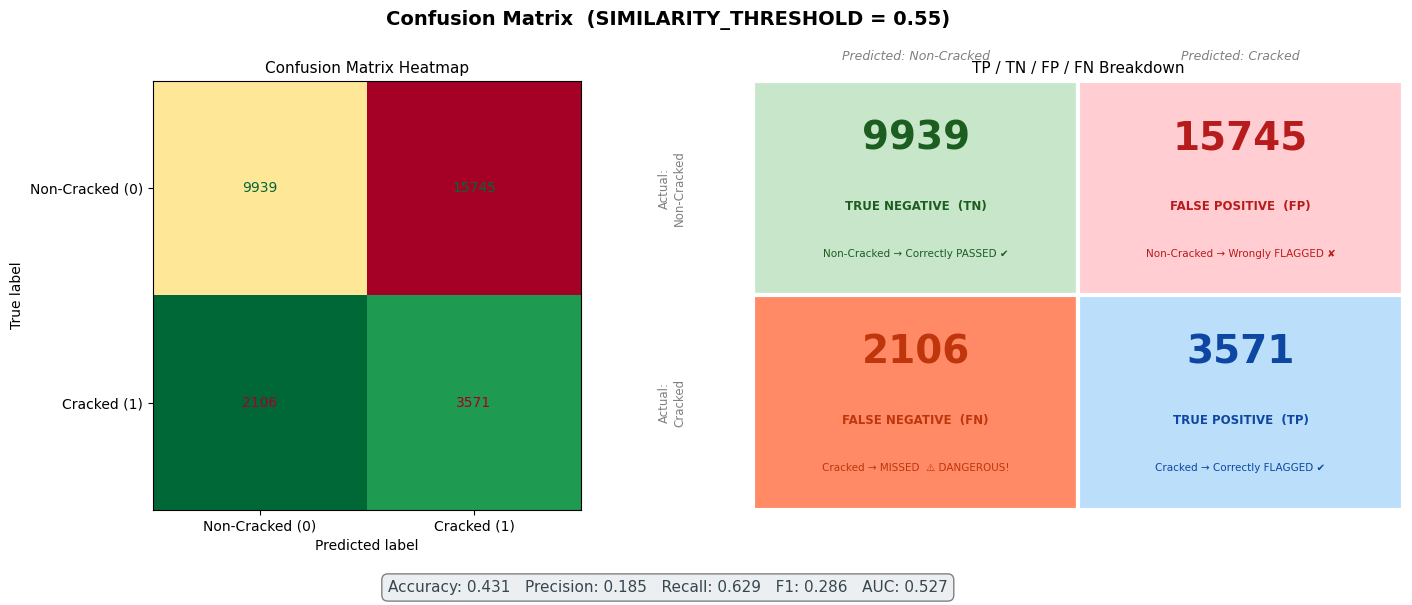

✔  Saved: confusion_matrix.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Confusion Matrix  (SIMILARITY_THRESHOLD = {SIMILARITY_THRESHOLD})",
             fontsize=14, fontweight="bold")

# Left — standard heatmap
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["Non-Cracked (0)", "Cracked (1)"]
                       ).plot(ax=axes[0], colorbar=False, cmap="RdYlGn_r")
axes[0].set_title("Confusion Matrix Heatmap", fontsize=11)

# Right — annotated breakdown
ax = axes[1]
ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.axis("off")
ax.set_title("TP / TN / FP / FN Breakdown", fontsize=11)

for (cx, cy, val, title, detail, bg, fg) in [
    (0, 1, tn, "TRUE NEGATIVE  (TN)",  "Non-Cracked → Correctly PASSED ✔", "#C8E6C9", "#1B5E20"),
    (1, 1, fp, "FALSE POSITIVE  (FP)", "Non-Cracked → Wrongly FLAGGED ✘",  "#FFCDD2", "#B71C1C"),
    (0, 0, fn, "FALSE NEGATIVE  (FN)", "Cracked → MISSED  ⚠ DANGEROUS!",   "#FF8A65", "#BF360C"),
    (1, 0, tp, "TRUE POSITIVE  (TP)",  "Cracked → Correctly FLAGGED ✔",     "#BBDEFB", "#0D47A1"),
]:
    ax.add_patch(plt.Rectangle((cx,cy),1,1, color=bg, ec="white", lw=3))
    ax.text(cx+0.5, cy+0.68, str(val),  ha="center", fontsize=28, fontweight="bold", color=fg)
    ax.text(cx+0.5, cy+0.40, title,     ha="center", fontsize=8.5, fontweight="bold", color=fg)
    ax.text(cx+0.5, cy+0.18, detail,    ha="center", fontsize=7.5, color=fg)

ax.text(0.5,  2.10, "Predicted: Non-Cracked", ha="center", fontsize=9, color="gray", style="italic")
ax.text(1.5,  2.10, "Predicted: Cracked",     ha="center", fontsize=9, color="gray", style="italic")
ax.text(-0.25, 1.5, "Actual:\nNon-Cracked",  ha="center", va="center", fontsize=8.5, color="gray", rotation=90)
ax.text(-0.25, 0.5, "Actual:\nCracked",      ha="center", va="center", fontsize=8.5, color="gray", rotation=90)

fig.text(0.5, 0.01,
         f"Accuracy: {acc:.3f}   Precision: {prec:.3f}   Recall: {rec:.3f}   F1: {f1:.3f}   AUC: {auc:.3f}",
         ha="center", fontsize=11, color="#37474F",
         bbox=dict(boxstyle="round,pad=0.4", fc="#ECEFF1", ec="gray"))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔  Saved: confusion_matrix.png")

## 📉 Cell 15 — Similarity Score Distribution

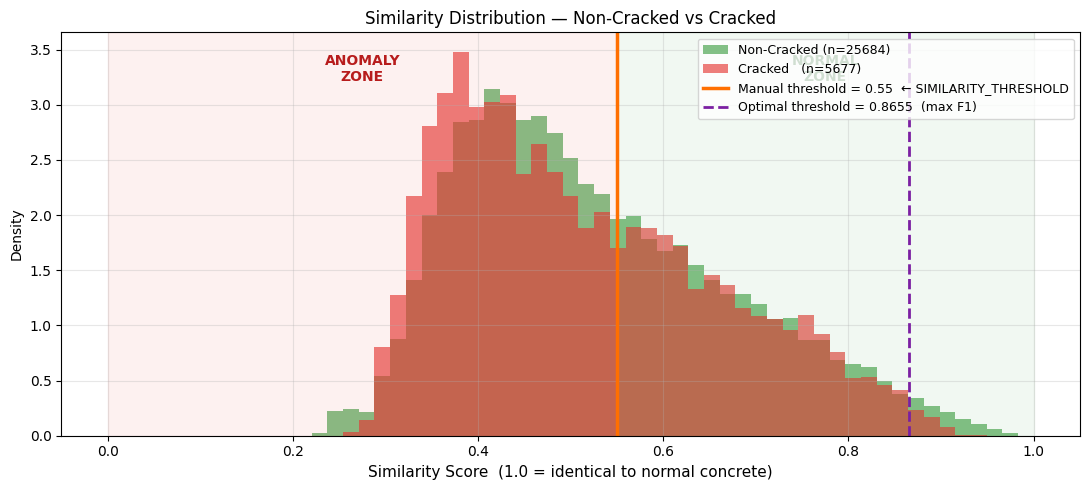

✔  Saved: similarity_distribution.png


In [15]:
sims_n = [r["similarity"] for r in records_normal]
sims_a = [r["similarity"] for r in records_anomaly]
bins   = np.linspace(0, 1, 60)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(sims_n, bins=bins, alpha=0.65, color="#43A047",
        label=f"Non-Cracked (n={len(sims_n)})", density=True)
ax.hist(sims_a, bins=bins, alpha=0.65, color="#E53935",
        label=f"Cracked   (n={len(sims_a)})", density=True)
ax.axvline(SIMILARITY_THRESHOLD, color="#FF6F00", lw=2.5,
           label=f"Manual threshold = {SIMILARITY_THRESHOLD}  ← SIMILARITY_THRESHOLD")
ax.axvline(best_thresh, color="#7B1FA2", lw=2, ls="--",
           label=f"Optimal threshold = {best_thresh:.4f}  (max F1)")

ymax = ax.get_ylim()[1]
ax.axvspan(0, SIMILARITY_THRESHOLD, alpha=0.07, color="#E53935")
ax.axvspan(SIMILARITY_THRESHOLD, 1, alpha=0.07, color="#43A047")
ax.text(SIMILARITY_THRESHOLD*0.5,      ymax*0.88, "ANOMALY\nZONE", color="#B71C1C",
        ha="center", fontsize=10, fontweight="bold")
ax.text((SIMILARITY_THRESHOLD+1)*0.5,  ymax*0.88, "NORMAL\nZONE",  color="#1B5E20",
        ha="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Similarity Score  (1.0 = identical to normal concrete)", fontsize=11)
ax.set_ylabel("Density"); ax.set_title("Similarity Distribution — Non-Cracked vs Cracked", fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("similarity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔  Saved: similarity_distribution.png")

## 📐 Cell 16 — ROC & Precision-Recall Curves

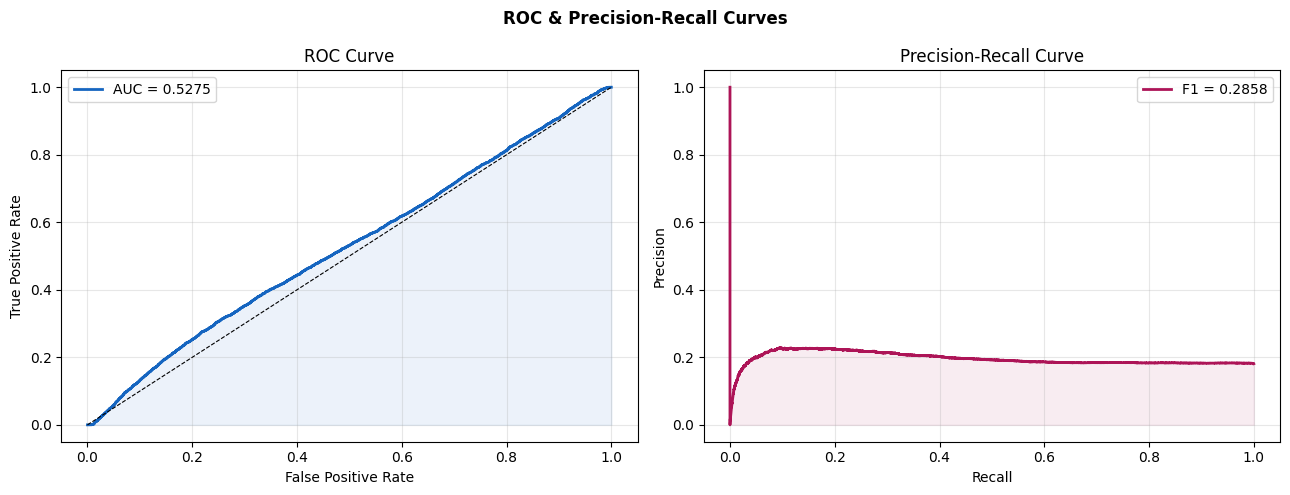

✔  Saved: roc_pr_curves.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ROC & Precision-Recall Curves", fontsize=12, fontweight="bold")

fpr, tpr, _ = roc_curve(y_true, y_scores)
axes[0].plot(fpr, tpr, color="#1565C0", lw=2, label=f"AUC = {auc:.4f}")
axes[0].fill_between(fpr, tpr, alpha=0.08, color="#1565C0")
axes[0].plot([0,1],[0,1],"k--", lw=0.8)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)

prec_c, rec_c, _ = precision_recall_curve(y_true, y_scores)
axes[1].plot(rec_c, prec_c, color="#AD1457", lw=2, label=f"F1 = {f1:.4f}")
axes[1].fill_between(rec_c, prec_c, alpha=0.08, color="#AD1457")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔  Saved: roc_pr_curves.png")

## 🎚️ Cell 17 — Threshold Sensitivity Analysis
Shows how TP/TN/FP/FN and F1 change as you move the threshold.  
Use this to pick the best `SIMILARITY_THRESHOLD` value for Cell 2.

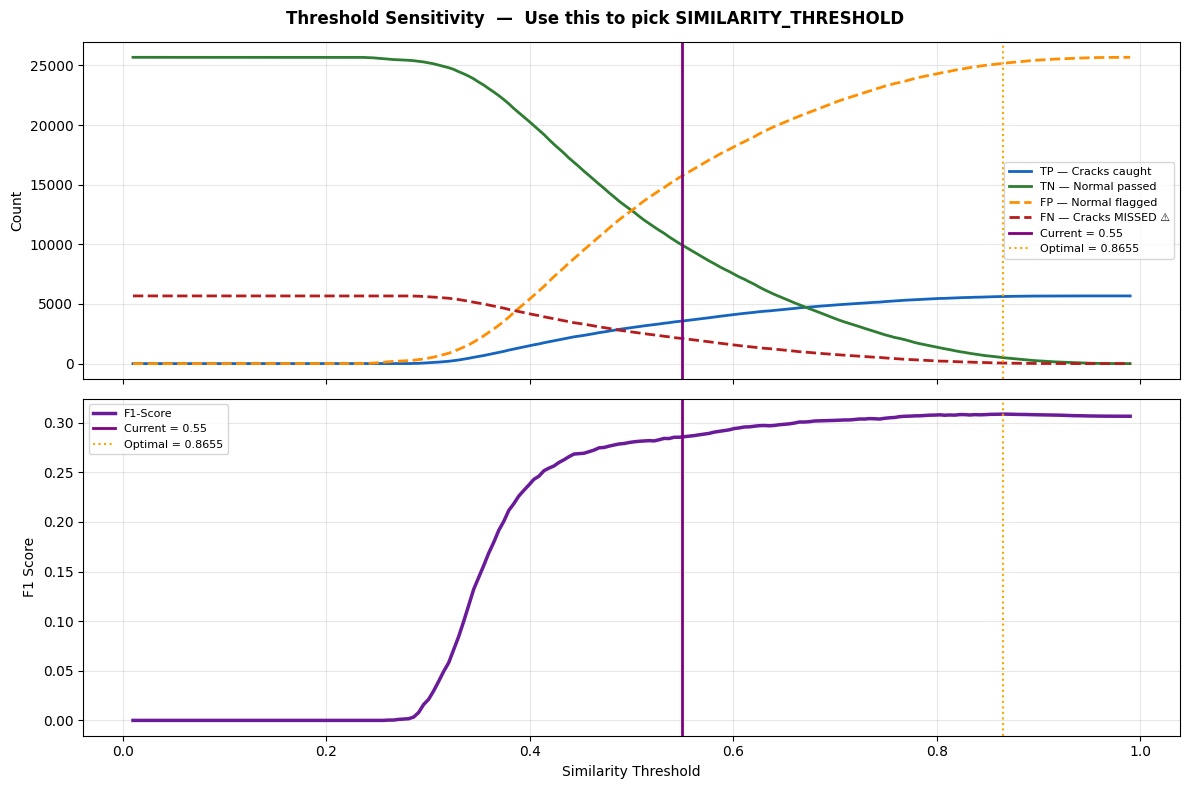

✔  Saved: threshold_sensitivity.png


In [17]:
all_s_arr = np.concatenate([
    np.array([r["similarity"] for r in records_normal]),
    np.array([r["similarity"] for r in records_anomaly])
])
y_true_arr = np.concatenate([
    np.zeros(len(records_normal)), np.ones(len(records_anomaly))
])

thresholds_sweep = np.linspace(0.01, 0.99, 200)
tps_s, tns_s, fps_s, fns_s, f1s_s = [], [], [], [], []

for t in thresholds_sweep:
    preds  = (all_s_arr < t).astype(int)
    cm_t   = confusion_matrix(y_true_arr, preds)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    tps_s.append(tp_t); tns_s.append(tn_t)
    fps_s.append(fp_t); fns_s.append(fn_t)
    f1s_s.append(f1_score(y_true_arr, preds, zero_division=0))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle("Threshold Sensitivity  —  Use this to pick SIMILARITY_THRESHOLD",
             fontsize=12, fontweight="bold")

ax1.plot(thresholds_sweep, tps_s, label="TP — Cracks caught",   color="#1565C0", lw=2)
ax1.plot(thresholds_sweep, tns_s, label="TN — Normal passed",   color="#2E7D32", lw=2)
ax1.plot(thresholds_sweep, fps_s, label="FP — Normal flagged",  color="#FF8F00", lw=2, ls="--")
ax1.plot(thresholds_sweep, fns_s, label="FN — Cracks MISSED ⚠", color="#B71C1C", lw=2, ls="--")
ax1.axvline(SIMILARITY_THRESHOLD, color="purple", lw=2,
            label=f"Current = {SIMILARITY_THRESHOLD}")
ax1.axvline(best_thresh, color="orange", lw=1.5, ls=":",
            label=f"Optimal = {best_thresh:.4f}")
ax1.set_ylabel("Count"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2.plot(thresholds_sweep, f1s_s, color="#6A1B9A", lw=2.5, label="F1-Score")
ax2.axvline(SIMILARITY_THRESHOLD, color="purple", lw=2,   label=f"Current = {SIMILARITY_THRESHOLD}")
ax2.axvline(best_thresh,          color="orange", lw=1.5, ls=":", label=f"Optimal = {best_thresh:.4f}")
ax2.set_xlabel("Similarity Threshold")
ax2.set_ylabel("F1 Score"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔  Saved: threshold_sensitivity.png")

## 📊 Cell 18 — Section Accuracy Charts

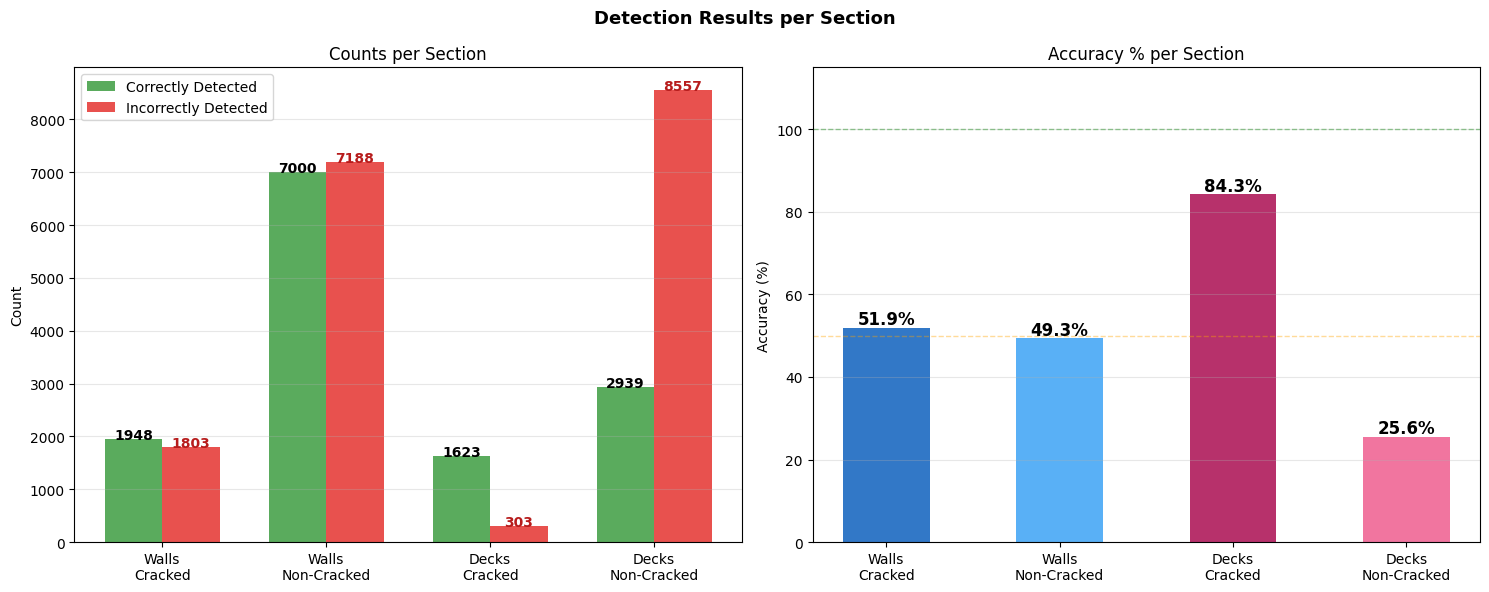

✔  Saved: section_accuracy.png


In [18]:
sections = [("Walls","Cracked"),("Walls","Non-Cracked"),
            ("Decks","Cracked"),("Decks","Non-Cracked")]
all_records = records_normal + records_anomaly

labels, correct_counts, incorrect_counts, pcts = [], [], [], []
for pool, section in sections:
    sub = [r for r in all_records if r["pool"]==pool and r["section"]==section]
    if not sub: continue
    nc = sum(r["correct"] for r in sub)
    labels.append(f"{pool}\n{section}")
    correct_counts.append(nc)
    incorrect_counts.append(len(sub)-nc)
    pcts.append(100*nc/len(sub))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Detection Results per Section", fontsize=13, fontweight="bold")

x = np.arange(len(labels)); w = 0.35
b1 = axes[0].bar(x-w/2, correct_counts,   w, label="Correctly Detected",   color="#43A047", alpha=0.88)
b2 = axes[0].bar(x+w/2, incorrect_counts, w, label="Incorrectly Detected", color="#E53935", alpha=0.88)
for b in b1:
    h = b.get_height()
    axes[0].text(b.get_x()+b.get_width()/2, h+0.3, str(int(h)), ha="center", fontsize=10, fontweight="bold")
for b in b2:
    h = b.get_height()
    axes[0].text(b.get_x()+b.get_width()/2, h+0.3, str(int(h)), ha="center", fontsize=10, fontweight="bold", color="#B71C1C")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=10)
axes[0].set_ylabel("Count"); axes[0].set_title("Counts per Section")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

bars = axes[1].bar(labels, pcts, color=["#1565C0","#42A5F5","#AD1457","#F06292"][:len(labels)],
                   alpha=0.88, width=0.5)
axes[1].axhline(100, color="green",  lw=1, ls="--", alpha=0.4)
axes[1].axhline(50,  color="orange", lw=1, ls="--", alpha=0.4, label="50% chance")
for b, p in zip(bars, pcts):
    axes[1].text(b.get_x()+b.get_width()/2, p+0.8, f"{p:.1f}%",
                 ha="center", fontsize=12, fontweight="bold")
axes[1].set_ylim(0, 115); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy % per Section"); axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("section_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔  Saved: section_accuracy.png")

## 🖼️ Cell 19 — Reconstruction Sample Grid

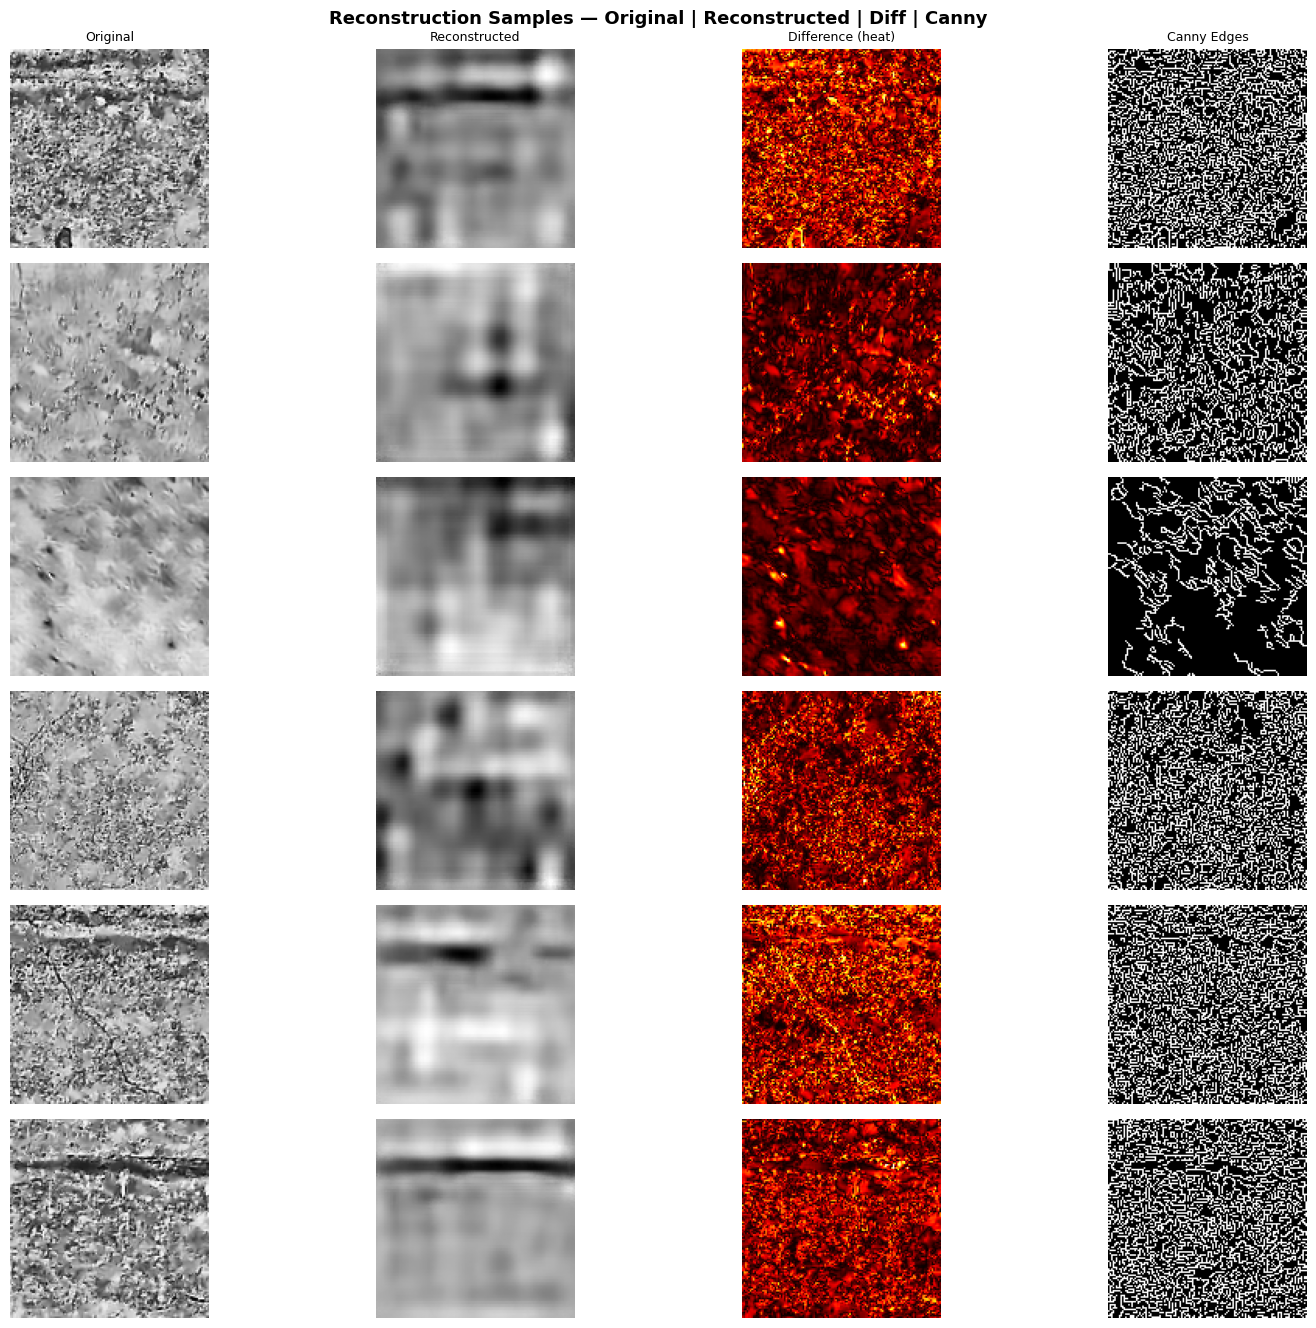

✔  Saved: reconstruction_samples.png


In [19]:
n = 3
recs_n_vis = autoencoder.predict(imgs_normal[:n],  batch_size=n, verbose=0)
recs_a_vis = autoencoder.predict(imgs_anomaly[:n], batch_size=n, verbose=0)

fig, axes = plt.subplots(n*2, 4, figsize=(16, n*4.5))
fig.suptitle("Reconstruction Samples — Original | Reconstructed | Diff | Canny",
             fontsize=13, fontweight="bold")
for j, t in enumerate(["Original","Reconstructed","Difference (heat)","Canny Edges"]):
    axes[0,j].set_title(t, fontsize=9)

pairs = (list(zip(imgs_normal[:n],  recs_n_vis, records_normal[:n])) +
         list(zip(imgs_anomaly[:n], recs_a_vis, records_anomaly[:n])))

for row, (orig, rec, meta) in enumerate(pairs):
    diff   = np.abs(orig - rec)
    canny  = cv2.Canny((orig.squeeze()*255).astype(np.uint8), 30, 100)
    color  = "#1B5E20" if meta["correct"] else "#B71C1C"
    status = "✔ CORRECT" if meta["correct"] else "✘ WRONG"

    axes[row,0].imshow(orig.squeeze(), cmap="gray")
    axes[row,1].imshow(rec.squeeze(),  cmap="gray")
    axes[row,2].imshow(diff.squeeze(), cmap="hot")
    axes[row,3].imshow(canny,          cmap="gray")
    for ax in axes[row]: ax.axis("off")
    axes[row,0].set_ylabel(
        f"{LABEL_NAMES[meta['label']]}\nSim={meta['similarity']:.3f}\n"
        f"Pred={LABEL_NAMES[meta['pred']]}\n{status}",
        fontsize=7, color=color, rotation=0, labelpad=90)

plt.tight_layout()
plt.savefig("reconstruction_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔  Saved: reconstruction_samples.png")

## ✅❌ Cell 20 — Correct & Incorrect Detection Grids per Section

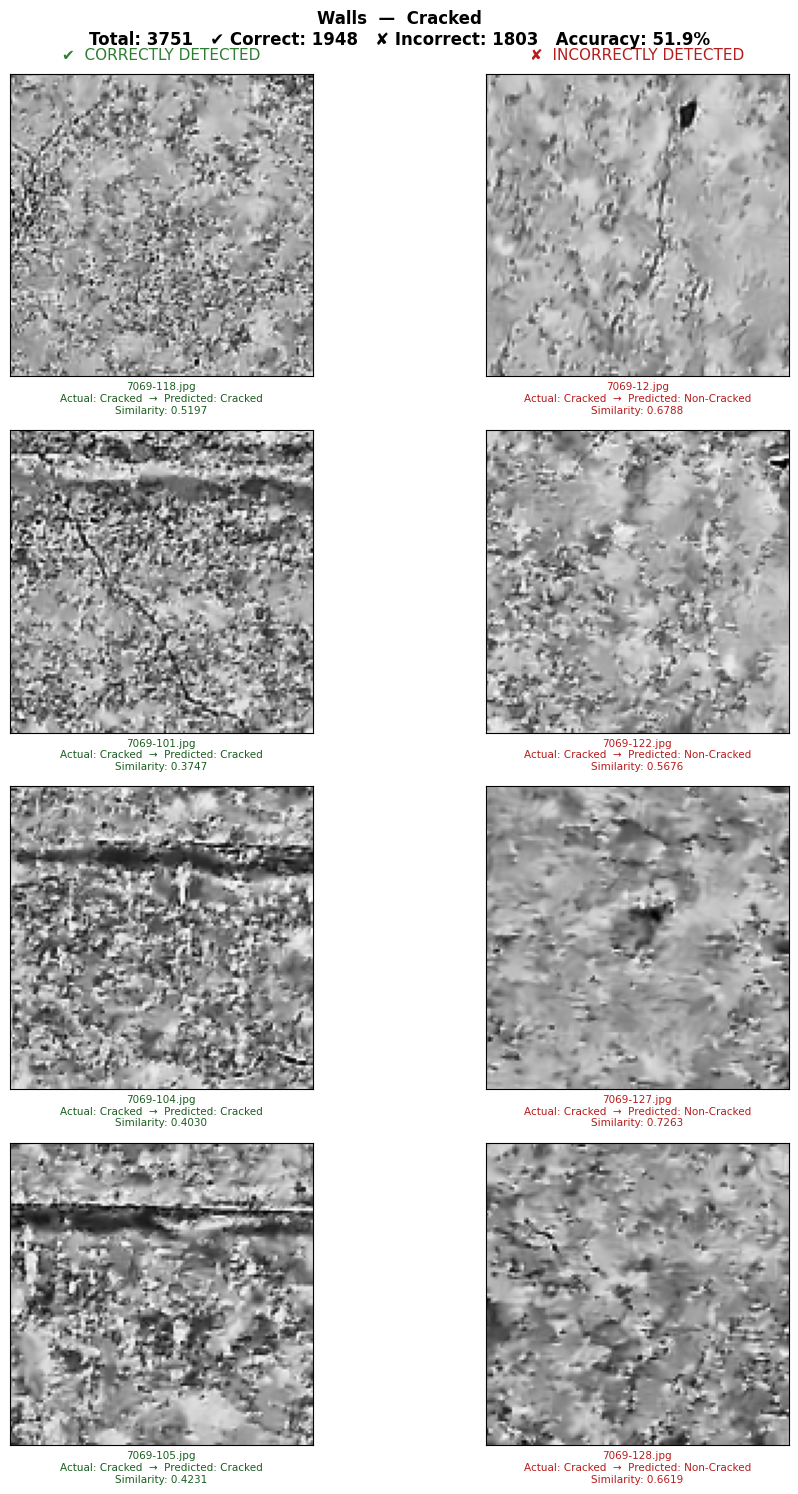

✔  Saved: grid_Walls_Cracked.png


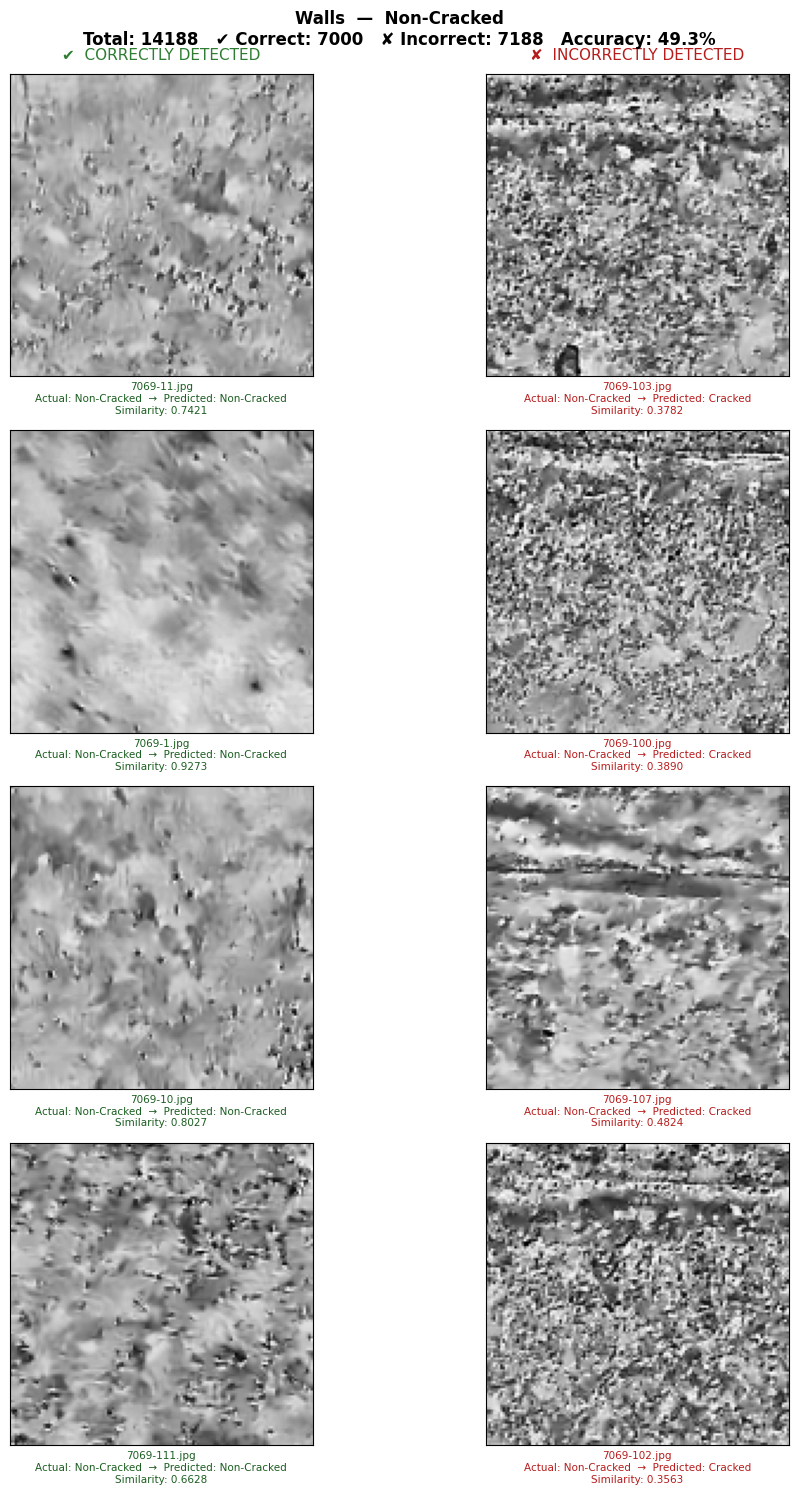

✔  Saved: grid_Walls_Non_Cracked.png


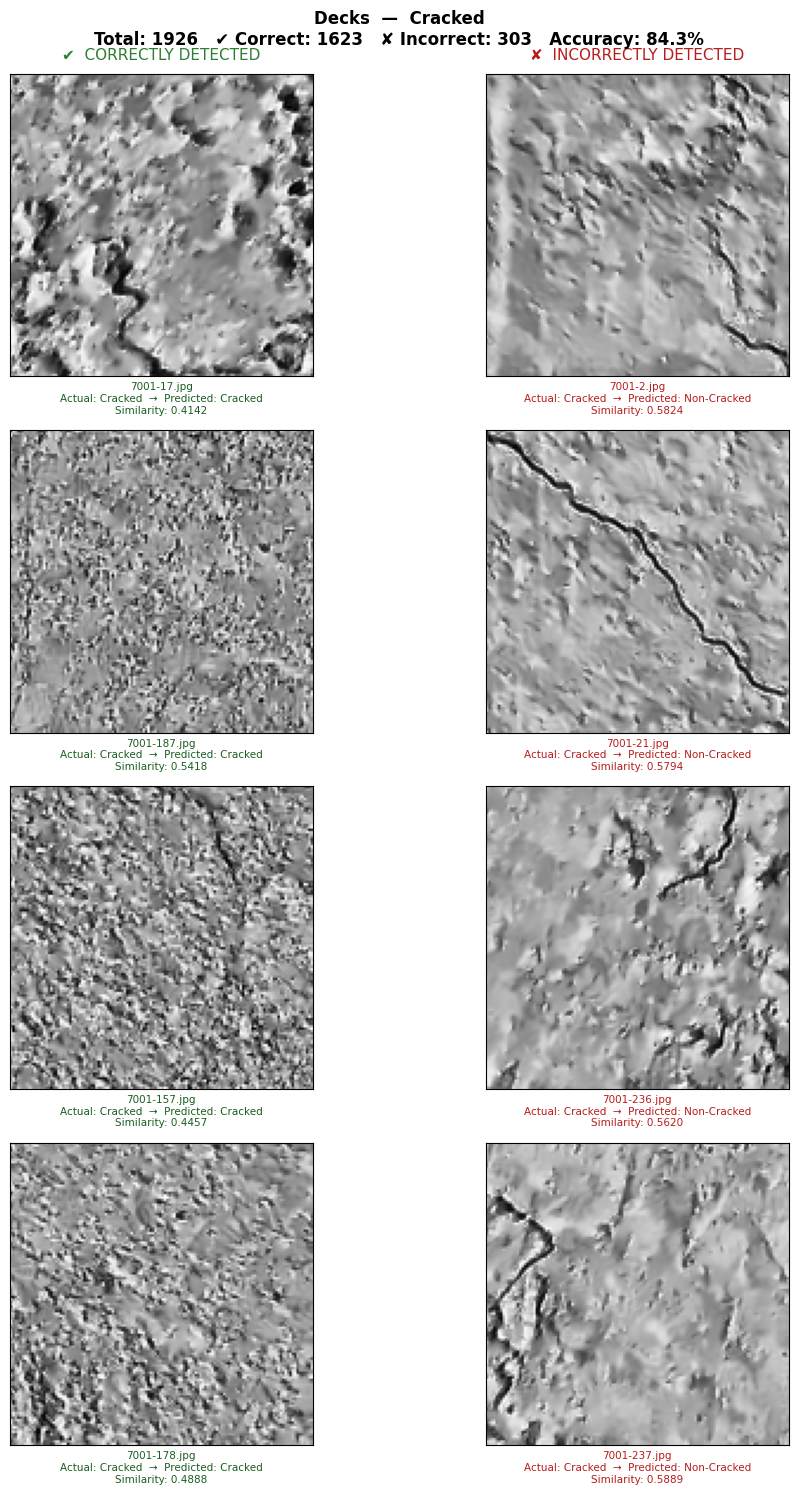

✔  Saved: grid_Decks_Cracked.png


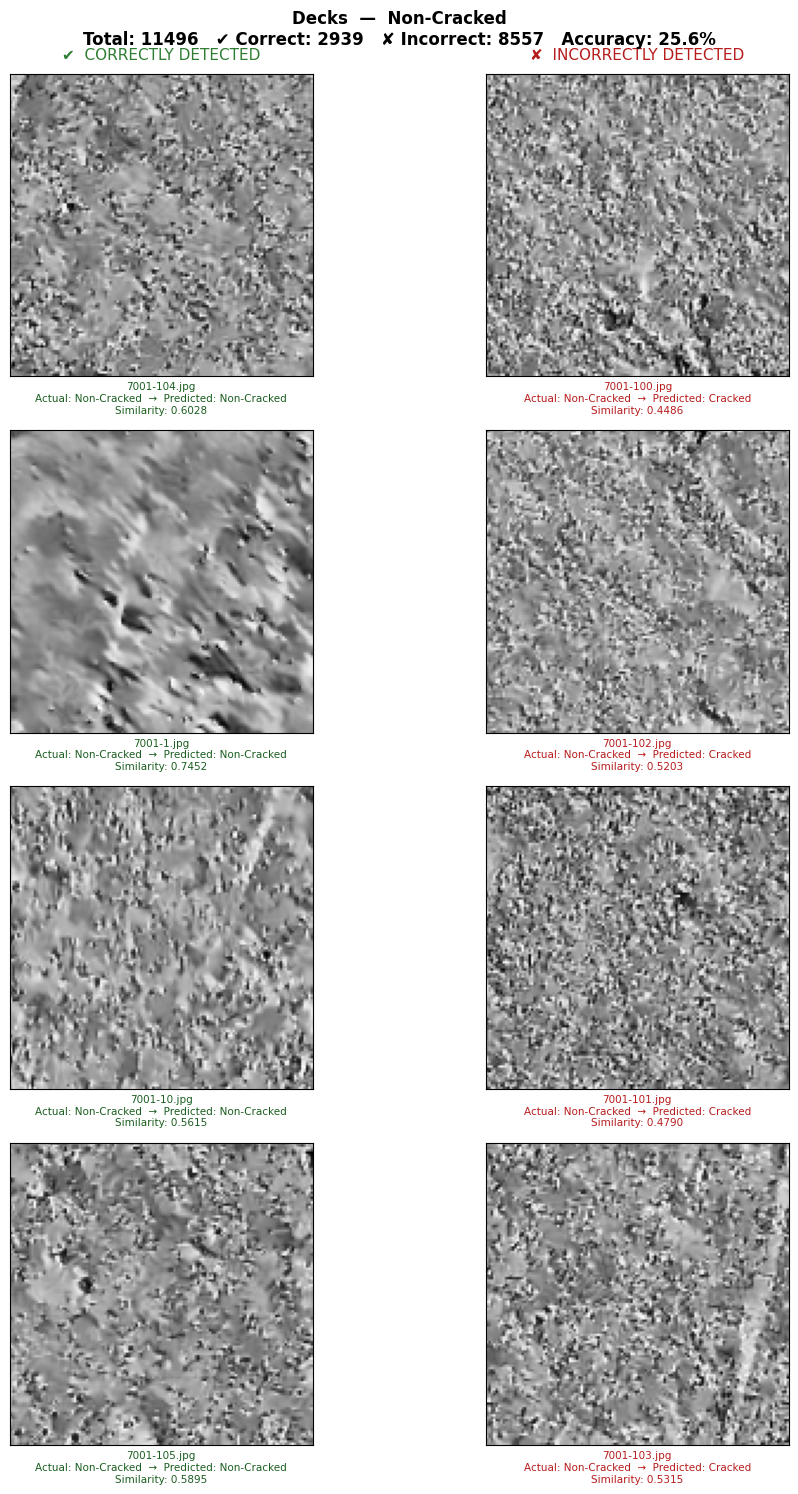

✔  Saved: grid_Decks_Non_Cracked.png


In [20]:
sections    = [("Walls","Cracked"),("Walls","Non-Cracked"),
               ("Decks","Cracked"),("Decks","Non-Cracked")]
all_records = records_normal + records_anomaly
n_each      = 4

for pool, section in sections:
    subset = [r for r in all_records if r["pool"]==pool and r["section"]==section]
    if not subset: continue

    correct_recs   = [r for r in subset if r["correct"]][:n_each]
    incorrect_recs = [r for r in subset if not r["correct"]][:n_each]
    n_rows = max(len(correct_recs), len(incorrect_recs))
    if n_rows == 0: continue

    fig, axes = plt.subplots(n_rows, 2, figsize=(11, n_rows*3.8))
    if n_rows == 1: axes = np.expand_dims(axes, 0)

    tc = sum(1 for r in subset if r["correct"])
    fig.suptitle(f"{pool}  —  {section}\n"
                 f"Total: {len(subset)}   ✔ Correct: {tc}   "
                 f"✘ Incorrect: {len(subset)-tc}   "
                 f"Accuracy: {100*tc/len(subset):.1f}%",
                 fontsize=12, fontweight="bold")
    axes[0,0].set_title("✔  CORRECTLY DETECTED",   color="#2E7D32", fontsize=11, pad=10)
    axes[0,1].set_title("✘  INCORRECTLY DETECTED", color="#B71C1C", fontsize=11, pad=10)

    for row in range(n_rows):
        for col, recs in enumerate([correct_recs, incorrect_recs]):
            ax = axes[row, col]
            if row < len(recs):
                r = recs[row]
                ax.imshow(preprocess(r["path"]).squeeze(), cmap="gray")
                ax.set_xlabel(
                    f"{r['filename']}\nActual: {LABEL_NAMES[r['label']]}  →  "
                    f"Predicted: {LABEL_NAMES[r['pred']]}\n"
                    f"Similarity: {r['similarity']:.4f}",
                    fontsize=7.5,
                    color="#1B5E20" if r["correct"] else "#B71C1C")
            else:
                ax.set_visible(False)
            ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    fname = f"grid_{pool}_{section.replace(' ','_').replace('-','_')}.png"
    plt.savefig(fname, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"✔  Saved: {fname}")

## 💾 Cell 21 — Save Model
*(Model is also auto-saved during training via ModelCheckpoint — this is a final explicit save)*

In [21]:
autoencoder.save(PATH_MODEL)
print(f"✔  Model saved: {PATH_MODEL}")
print(f"   ref_mse = {ref_mse:.6f}  (needed for single-image inference)")

✔  Model saved: ae_checkpoints\autoencoder.keras
   ref_mse = 0.023576  (needed for single-image inference)


## 🔎 Cell 22 — Single Image Inference
Uncomment the last line and set your image path.

In [22]:
def predict_image(img_path: str):
    """Run anomaly detection on one new image."""
    img   = preprocess(img_path)
    rec   = autoencoder.predict(img[np.newaxis,...], verbose=0)[0]
    error = float(np.mean((img - rec)**2))
    sim   = error_to_similarity(error, ref_mse)
    pred  = "🔴 CRACKED (ANOMALY)" if sim < SIMILARITY_THRESHOLD else "🟢 NON-CRACKED (NORMAL)"

    print(f"  Image      : {img_path}")
    print(f"  Error      : {error:.6f}")
    print(f"  Similarity : {sim:.4f}  (threshold = {SIMILARITY_THRESHOLD})")
    print(f"  Result     : {pred}")

    diff  = np.abs(img.squeeze() - rec.squeeze())
    canny = cv2.Canny((img.squeeze()*255).astype(np.uint8), 30, 100)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"{pred}   |   Similarity = {sim:.4f}   |   Threshold = {SIMILARITY_THRESHOLD}")
    for ax, im, cmap, title in zip(
        axes,
        [img.squeeze(), rec.squeeze(), diff, canny],
        ["gray","gray","hot","gray"],
        ["Original","Reconstructed","Difference","Canny"]
    ):
        ax.imshow(im, cmap=cmap); ax.set_title(title); ax.axis("off")
    plt.tight_layout(); plt.show()


# ── Uncomment and set path to run on a new image ──────────────────────────────
# predict_image(r"C:\path\to\your\image.jpg")